# STEMNIST数据训练与识别

In [1]:
import torch
import torch.nn as nn
from spikingjelly.activation_based import functional

## 1. 参数定义

In [2]:
EXPERIMENT_NAME = "T20_scheduler_dropout_0.1"
BATCH_SIZE = 64
TIME_STEPS = 20
DROPOUT_RATE = 0.1

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 100

## 2. 数据

In [3]:
from data_utils_slow import make_dataloaders

In [4]:
train_loader, val_loader, test_loader = make_dataloaders(time_steps=TIME_STEPS, batch_size=BATCH_SIZE)

开始预读取 7700 个样本……
已读取 500/7700
已读取 1000/7700
已读取 1500/7700
已读取 2000/7700
已读取 2500/7700
已读取 3000/7700
已读取 3500/7700
已读取 4000/7700
已读取 4500/7700
已读取 5000/7700
已读取 5500/7700
已读取 6000/7700
已读取 6500/7700
已读取 7000/7700
已读取 7500/7700
预读取完成： torch.Size([7700, 20, 1, 16, 16]) torch.uint8


In [5]:
# 检查单元
batch = next(iter(train_loader))
inputs, labels = batch[:2]

print("DataLoader 输入形状：", inputs.shape)
print("标签形状：", labels.shape)

expected_shape = (
    inputs.shape[0],
    TIME_STEPS,
    1,
    16,
    16,
)

assert tuple(inputs.shape) == expected_shape, (
    f"输入形状错误：期望 {expected_shape}，"
    f"实际为 {tuple(inputs.shape)}"
)

snn_inputs = inputs.permute(
    1, 0, 2, 3, 4
).contiguous()

print("SNN 输入形状：", snn_inputs.shape)

assert snn_inputs.shape[0] == TIME_STEPS

DataLoader 输入形状： torch.Size([64, 20, 1, 16, 16])
标签形状： torch.Size([64])
SNN 输入形状： torch.Size([20, 64, 1, 16, 16])


## 3. 模型

In [6]:
from model import ConvSNN

In [7]:
model = ConvSNN(num_classes=35, dropout=DROPOUT_RATE, tau=10.0, logit_scale=10.0).to(DEVICE)

In [8]:
model.parameter_count()

6379

## 4. 损失优化

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-3,
    min_lr=1e-5
)

## 5.训练

In [10]:
from function_utils import train_epoch, validate_epoch, train_model

In [11]:
# train_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch=1)

In [12]:
# validate_epoch(
#     model=model,
#     val_loader=val_loader,
#     criterion=criterion,
#     device=DEVICE,
#     epoch=1
# )

In [13]:
history = train_model(model, 
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            num_epochs=NUM_EPOCHS,
            save_path=f"../outputs/{EXPERIMENT_NAME}/best_model.pt",
            scheduler=scheduler
)

Train Epoch 1:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.031153 | lif2=0.003461 | output=0.000735

Epoch 001/100 | Train loss: 3.5560 | Train accuracy: 0.0321 | Val loss: 3.5530 | Val accuracy: 0.0381 | LR: 0.001
✓ 保存最佳模型：../outputs/T20_scheduler_dropout_0.1/best_model.pt
  epoch=1, val_accuracy=0.0381


Train Epoch 2:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 2:   0%|          | 0/20 [00:00<?, ?it/s]

...

Val Epoch 99:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.000660 | lif2=0.005301 | output=0.031394

Epoch 099/100 | Train loss: 3.1954 | Train accuracy: 0.1552 | Val loss: 3.2213 | Val accuracy: 0.1372 | LR: 1e-05


Train Epoch 100:   0%|          | 0/77 [00:00<?, ?it/s]

Val Epoch 100:   0%|          | 0/20 [00:00<?, ?it/s]

Validation firing rates | lif1=0.000659 | lif2=0.005290 | output=0.031804

Epoch 100/100 | Train loss: 3.2000 | Train accuracy: 0.1498 | Val loss: 3.2208 | Val accuracy: 0.1396 | LR: 1e-05

训练完成
最佳 epoch：14
最佳验证集准确率：0.2825
最佳模型路径：../outputs/T20_scheduler_dropout_0.1/best_model.pt


## 6. 结果可视化与数据保存

In [14]:
from function_utils import plot_training_history

训练曲线已保存：/root/autodl-tmp/SNN_for_STEMNIST/first_stage/outputs/T20_scheduler_dropout_0.1/training_history.png


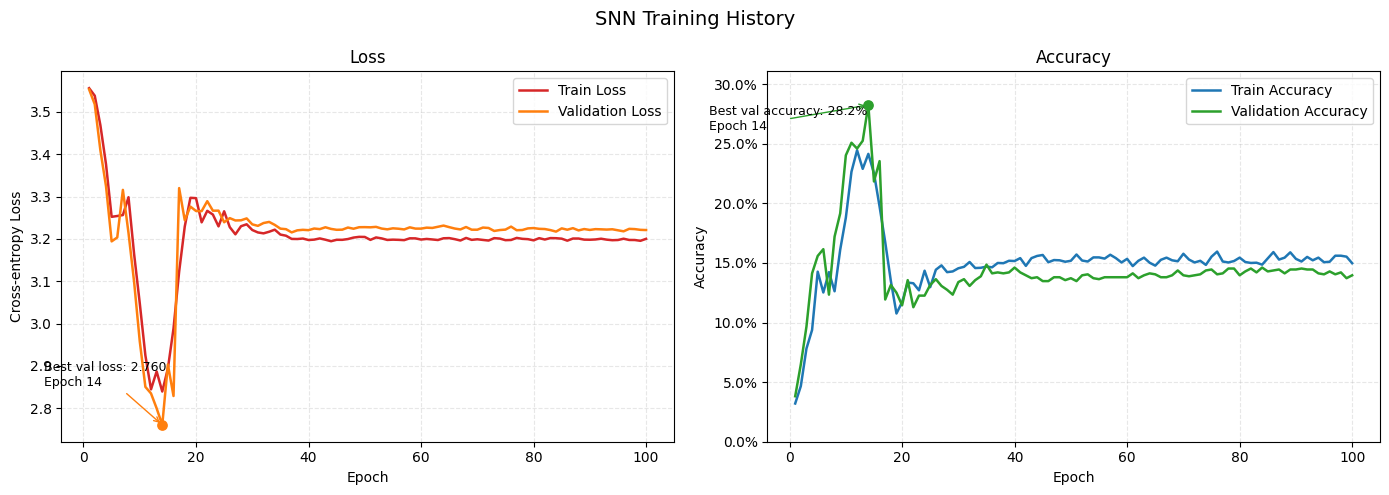

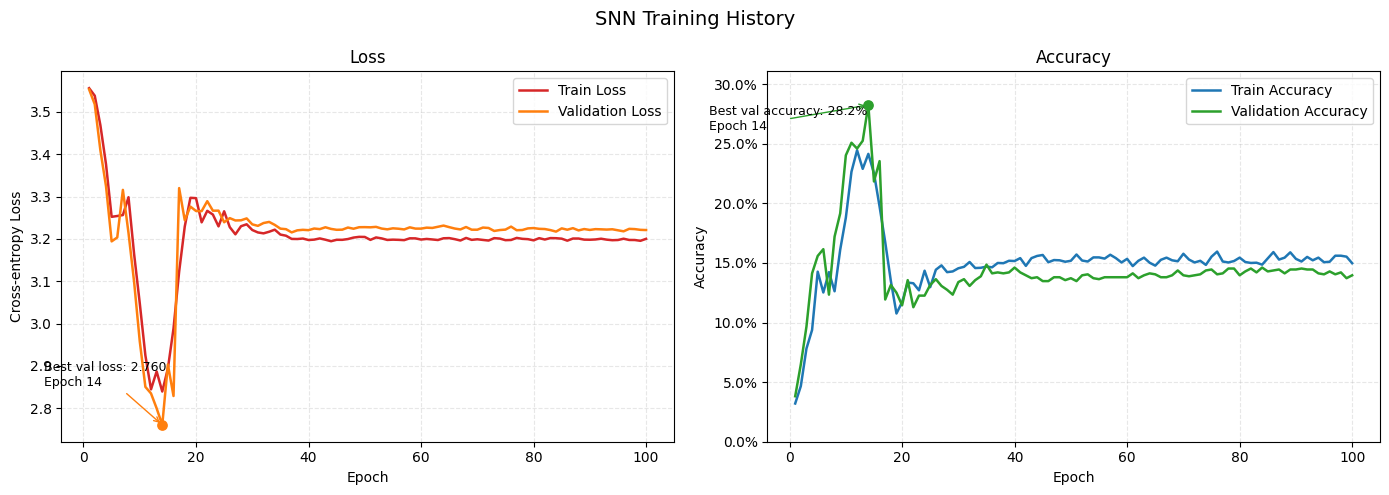

In [15]:
plot_training_history(
    history,
    save_path=f"../outputs/{EXPERIMENT_NAME}/training_history.png",
)

In [16]:
# 保存history为csv文件
import pandas as pd
history_df = pd.DataFrame(history)
history_df.to_csv(f"../outputs/{EXPERIMENT_NAME}/training_history.csv", index=False)